In [12]:

# STEP 1 — LOAD DATASET
# Note: the file has a .csv extension but is actually an XLSX

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Read as Excel, not CSV
df = pd.read_excel('/content/Maths.csv', engine='openpyxl')

print(f"Rows:    {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn names:\n{list(df.columns)}")

df.head()

Rows:    397
Columns: 33

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [11]:
# Save a proper CSV version for the repository
df.to_csv('/content/student_math.csv', index=False)
print("Clean CSV saved as student_math.csv")

Clean CSV saved as student_math.csv


In [13]:
# STEP 2 — STRUCTURAL INSPECTION

print("=" * 60)
print("DATA TYPES AND NON-NULL COUNTS")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("MISSING VALUES PER COLUMN")
print("=" * 60)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)
dups = df.duplicated().sum()
print(f"Fully duplicated rows: {dups}")

if dups > 0:
    print("\nPreview of duplicated rows:")
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10))

DATA TYPES AND NON-NULL COUNTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      397 non-null    object
 1   sex         397 non-null    object
 2   age         397 non-null    int64 
 3   address     397 non-null    object
 4   famsize     397 non-null    object
 5   Pstatus     397 non-null    object
 6   Medu        397 non-null    int64 
 7   Fedu        397 non-null    int64 
 8   Mjob        397 non-null    object
 9   Fjob        397 non-null    object
 10  reason      397 non-null    object
 11  guardian    397 non-null    object
 12  traveltime  397 non-null    int64 
 13  studytime   397 non-null    int64 
 14  failures    397 non-null    int64 
 15  schoolsup   397 non-null    object
 16  famsup      397 non-null    object
 17  paid        397 non-null    object
 18  activities  397 non-null    object
 19  nursery     397 non

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
395,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
383,MS,M,19,R,GT3,T,1,1,other,services,other,mother,2,1,1,no,no,no,no,yes,yes,no,no,4,3,2,1,3,5,0,6,5,0
396,MS,M,19,R,GT3,T,1,1,other,services,other,mother,2,1,1,no,no,no,no,yes,yes,no,no,4,3,2,1,3,5,0,6,5,0


In [14]:

# STEP 3 — DATA CLEANING & TARGET DEFINITION

# --- 3.1 Remove exact duplicate rows ---
rows_before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
rows_after = df.shape[0]

print(f"Rows before : {rows_before}")
print(f"Rows after  : {rows_after}")
print(f"Removed     : {rows_before - rows_after} duplicate rows")
print(f"Matches the original UCI dataset (395 rows): {rows_after == 395}")


# --- 3.2 Define the classification target ---
# Portuguese grading scale: 0-20. Pass mark is 10.
PASS_MARK = 10
df['passed'] = (df['G3'] >= PASS_MARK).astype(int)   # 1 = pass, 0 = fail

print("\n" + "=" * 60)
print("CLASSIFICATION TARGET: 'passed'")
print("=" * 60)
counts = df['passed'].value_counts().sort_index()
pct = df['passed'].value_counts(normalize=True).sort_index() * 100

for label, name in [(0, 'Fail'), (1, 'Pass')]:
    print(f"{name:5} ({label}) : {counts[label]:3d} students  ({pct[label]:.1f}%)")


# --- 3.3 Quick look at the regression target ---
print("\n" + "=" * 60)
print("REGRESSION TARGET: 'G3' (final grade)")
print("=" * 60)
print(df['G3'].describe().round(2))
print(f"\nStudents with G3 = 0 : {(df['G3'] == 0).sum()}")

Rows before : 397
Rows after  : 395
Removed     : 2 duplicate rows
Matches the original UCI dataset (395 rows): True

CLASSIFICATION TARGET: 'passed'
Fail  (0) : 130 students  (32.9%)
Pass  (1) : 265 students  (67.1%)

REGRESSION TARGET: 'G3' (final grade)
count    395.00
mean      10.42
std        4.58
min        0.00
25%        8.00
50%       11.00
75%       14.00
max       20.00
Name: G3, dtype: float64

Students with G3 = 0 : 38


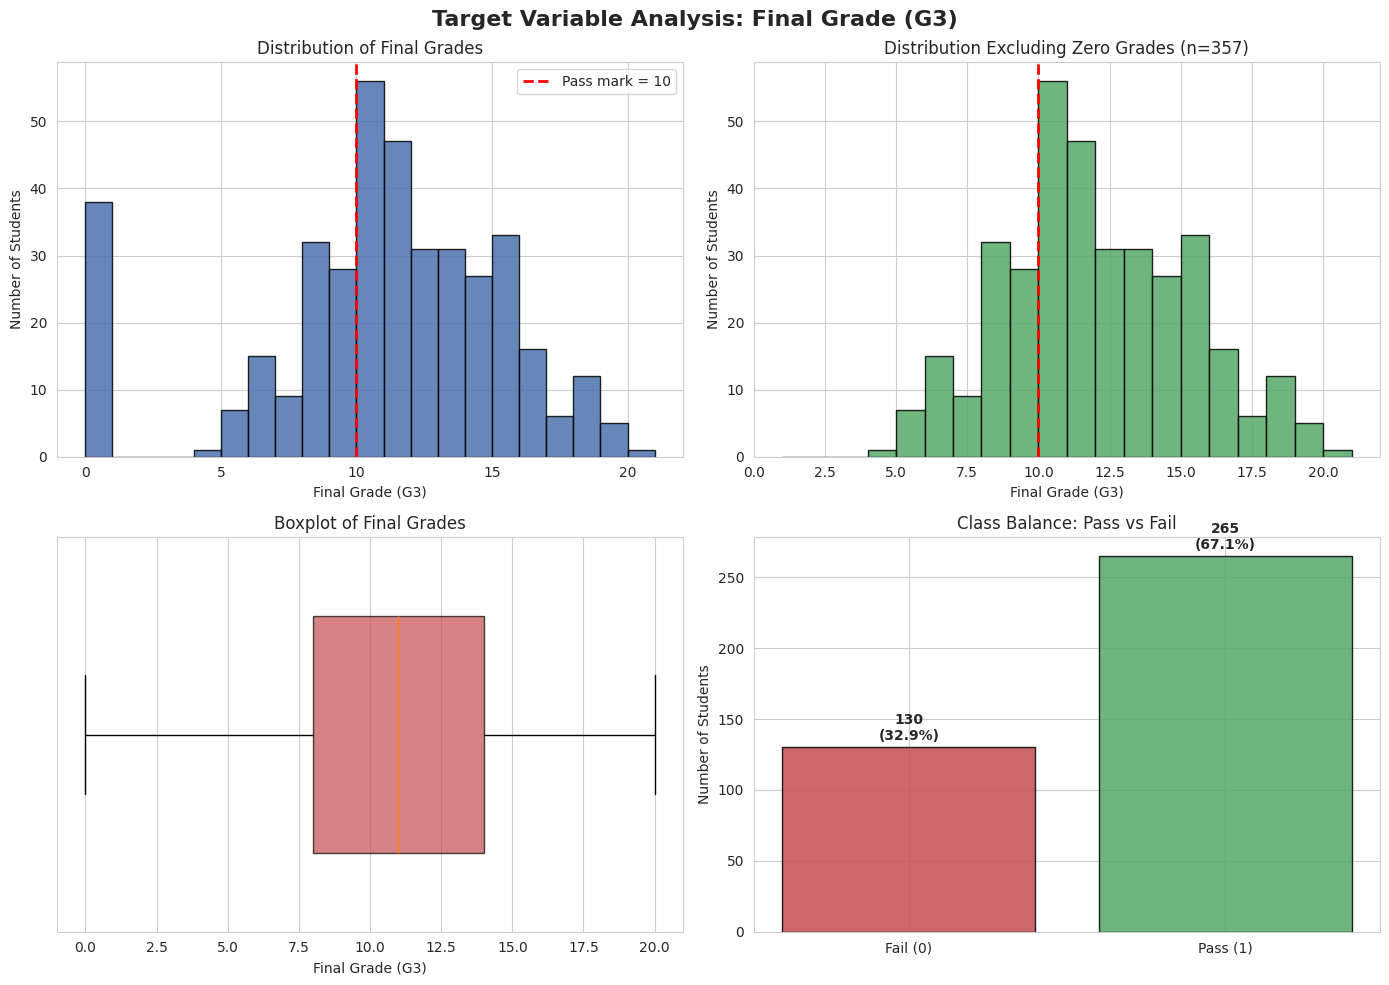

In [15]:

# STEP 4 — TARGET VARIABLE VISUALIZATION (Matplotlib)

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Target Variable Analysis: Final Grade (G3)',
             fontsize=16, fontweight='bold')


# --- [0,0] Histogram of all final grades ---
axes[0, 0].hist(df['G3'], bins=21, range=(0, 21),
                color='#4C72B0', edgecolor='black', alpha=0.85)
axes[0, 0].axvline(PASS_MARK, color='red', linestyle='--',
                   linewidth=2, label=f'Pass mark = {PASS_MARK}')
axes[0, 0].set_title('Distribution of Final Grades')
axes[0, 0].set_xlabel('Final Grade (G3)')
axes[0, 0].set_ylabel('Number of Students')
axes[0, 0].legend()


# --- [0,1] Same histogram, zeros excluded ---
axes[0, 1].hist(df.loc[df['G3'] > 0, 'G3'], bins=20, range=(1, 21),
                color='#55A868', edgecolor='black', alpha=0.85)
axes[0, 1].axvline(PASS_MARK, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('Distribution Excluding Zero Grades (n=357)')
axes[0, 1].set_xlabel('Final Grade (G3)')
axes[0, 1].set_ylabel('Number of Students')


# --- [1,0] Boxplot to expose outliers ---
axes[1, 0].boxplot(df['G3'], vert=False, widths=0.6,
                   patch_artist=True,
                   boxprops=dict(facecolor='#C44E52', alpha=0.7))
axes[1, 0].set_title('Boxplot of Final Grades')
axes[1, 0].set_xlabel('Final Grade (G3)')
axes[1, 0].set_yticks([])


# --- [1,1] Class balance for the classification target ---
class_counts = df['passed'].value_counts().sort_index()
bars = axes[1, 1].bar(['Fail (0)', 'Pass (1)'], class_counts.values,
                      color=['#C44E52', '#55A868'],
                      edgecolor='black', alpha=0.85)
axes[1, 1].set_title('Class Balance: Pass vs Fail')
axes[1, 1].set_ylabel('Number of Students')

# Annotate each bar with count and percentage
for bar, count in zip(bars, class_counts.values):
    pct = count / len(df) * 100
    axes[1, 1].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 5,
                    f'{count}\n({pct:.1f}%)',
                    ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('target_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# STEP 5 — OUTLIER DETECTION
# Two complementary approaches:
#   (a) Statistical  -> IQR method across all numeric features
#   (b) Domain-based -> contextual anomalies statistics cannot see

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'passed']

# --- (a) IQR method ---
print("=" * 70)
print("IQR OUTLIER DETECTION (1.5 x IQR rule)")
print("=" * 70)
print(f"{'Feature':<12}{'Q1':>7}{'Q3':>7}{'IQR':>7}{'Lower':>9}{'Upper':>9}{'Outliers':>10}")
print("-" * 70)

outlier_summary = {}

for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_out
    flag = "  <<<" if n_out > 0 else ""
    print(f"{col:<12}{q1:>7.1f}{q3:>7.1f}{iqr:>7.1f}{lower:>9.1f}{upper:>9.1f}{n_out:>10}{flag}")


# --- (b) Domain-based anomaly: dropouts ---
print("\n" + "=" * 70)
print("DOMAIN-BASED ANOMALY: ZERO FINAL GRADES")
print("=" * 70)

df['dropout_flag'] = (df['G3'] == 0).astype(int)
n_drop = df['dropout_flag'].sum()

q1, q3 = df['G3'].quantile([0.25, 0.75])
lower_fence = q1 - 1.5 * (q3 - q1)

print(f"Students with G3 = 0            : {n_drop} ({n_drop/len(df)*100:.1f}%)")
print(f"IQR lower fence for G3          : {lower_fence:.1f}")
print(f"Flagged as outliers by IQR      : {outlier_summary['G3']}")
print("\n>> The IQR rule detects none of them, yet the histogram shows a clear")
print(">> isolated cluster at zero. Statistical rules alone are not sufficient;")
print(">> domain knowledge is required to identify meaningful anomalies.")


# --- Do these students differ in earlier terms? ---
print("\n" + "=" * 70)
print("PROFILE COMPARISON: DROPOUTS vs REST")
print("=" * 70)
comparison = df.groupby('dropout_flag')[
    ['G1', 'G2', 'absences', 'failures', 'studytime', 'age']
].mean().round(2)
comparison.index = ['Completed (G3 > 0)', 'Dropout (G3 = 0)']
display(comparison)

IQR OUTLIER DETECTION (1.5 x IQR rule)
Feature          Q1     Q3    IQR    Lower    Upper  Outliers
----------------------------------------------------------------------
age            16.0   18.0    2.0     13.0     21.0         1  <<<
Medu            2.0    4.0    2.0     -1.0      7.0         0
Fedu            2.0    3.0    1.0      0.5      4.5         2  <<<
traveltime      1.0    2.0    1.0     -0.5      3.5         8  <<<
studytime       1.0    2.0    1.0     -0.5      3.5        27  <<<
failures        0.0    0.0    0.0      0.0      0.0        83  <<<
famrel          4.0    5.0    1.0      2.5      6.5        26  <<<
freetime        3.0    4.0    1.0      1.5      5.5        19  <<<
goout           2.0    4.0    2.0     -1.0      7.0         0
Dalc            1.0    2.0    1.0     -0.5      3.5        18  <<<
Walc            1.0    3.0    2.0     -2.0      6.0         0
health          3.0    5.0    2.0      0.0      8.0         0
absences        0.0    8.0    8.0    -12.0  

,G1,G2,absences,failures,studytime,age
Completed (G3 > 0),11.27,11.36,6.32,0.27,2.04,16.66
Dropout (G3 = 0),7.53,4.66,0.00,0.92,1.97,17.08


In [17]:
# STEP 6 — VALIDATE THE 'absences' ANOMALY
# Question: is absences=0 a genuine predictor, or an artifact of
#           students being administratively deregistered?

print("=" * 70)
print("A) IS ZERO-ABSENCE UNIVERSAL AMONG DROPOUTS?")
print("=" * 70)
drop = df[df['dropout_flag'] == 1]
print(f"Dropouts total                  : {len(drop)}")
print(f"Dropouts with absences = 0      : {(drop['absences'] == 0).sum()}")
print(f"Dropouts with absences > 0      : {(drop['absences'] > 0).sum()}")


print("\n" + "=" * 70)
print("B) HOW COMMON IS ZERO-ABSENCE OVERALL?")
print("=" * 70)
comp = df[df['dropout_flag'] == 0]
print(f"Completed students with absences = 0 : {(comp['absences'] == 0).sum()} "
      f"of {len(comp)} ({(comp['absences'] == 0).mean()*100:.1f}%)")


print("\n" + "=" * 70)
print("C) PREDICTIVE POWER OF THE ZERO-ABSENCE RULE")
print("=" * 70)
zero_abs = df[df['absences'] == 0]
print(f"Students with absences = 0      : {len(zero_abs)}")
print(f"   of which dropped out         : {zero_abs['dropout_flag'].sum()} "
      f"({zero_abs['dropout_flag'].mean()*100:.1f}%)")
print("\n>> If this rate is close to the 9.6% base rate, zero-absence is common")
print(">> and harmless. If it is far higher, the feature leaks the outcome.")


print("\n" + "=" * 70)
print("D) GRADE TRAJECTORY G1 -> G2 -> G3")
print("=" * 70)
traj = df.groupby('dropout_flag')[['G1', 'G2', 'G3']].mean().round(2)
traj.index = ['Completed', 'Dropout']
traj['G1_to_G2'] = (traj['G2'] - traj['G1']).round(2)
display(traj)

A) IS ZERO-ABSENCE UNIVERSAL AMONG DROPOUTS?
Dropouts total                  : 38
Dropouts with absences = 0      : 38
Dropouts with absences > 0      : 0

B) HOW COMMON IS ZERO-ABSENCE OVERALL?
Completed students with absences = 0 : 77 of 357 (21.6%)

C) PREDICTIVE POWER OF THE ZERO-ABSENCE RULE
Students with absences = 0      : 115
   of which dropped out         : 38 (33.0%)

>> If this rate is close to the 9.6% base rate, zero-absence is common
>> and harmless. If it is far higher, the feature leaks the outcome.

D) GRADE TRAJECTORY G1 -> G2 -> G3


,G1,G2,G3,G1_to_G2
Completed,11.27,11.36,11.52,0.09
Dropout,7.53,4.66,0.00,-2.87


In [18]:

# STEP 7 — ENCODING & CORRELATION ANALYSIS

df_enc = df.copy()

# --- 7.1 Binary categorical -> 0/1 ---
binary_map = {
    'school'   : {'GP': 0, 'MS': 1},
    'sex'      : {'F': 0, 'M': 1},
    'address'  : {'R': 0, 'U': 1},
    'famsize'  : {'GT3': 0, 'LE3': 1},
    'Pstatus'  : {'A': 0, 'T': 1},
}
yes_no_cols = ['schoolsup', 'famsup', 'paid', 'activities',
               'nursery', 'higher', 'internet', 'romantic']

for col, mapping in binary_map.items():
    df_enc[col] = df_enc[col].map(mapping)

for col in yes_no_cols:
    df_enc[col] = df_enc[col].map({'no': 0, 'yes': 1})

# --- 7.2 Nominal categorical -> one-hot ---
nominal_cols = ['Mjob', 'Fjob', 'reason', 'guardian']
df_enc = pd.get_dummies(df_enc, columns=nominal_cols, drop_first=True, dtype=int)

print(f"Shape after encoding: {df_enc.shape}")
print(f"Remaining object columns: {list(df_enc.select_dtypes('object').columns)}")


# --- 7.3 Define what must NEVER be used as a feature ---
LEAKY = ['G1', 'G2',          # earlier grades -> trivially predict G3
         'dropout_flag',      # derived from G3 itself
         'passed']            # the classification target
TARGET_REG = 'G3'

feature_cols = [c for c in df_enc.columns if c not in LEAKY + [TARGET_REG]]
print(f"\nUsable features: {len(feature_cols)}")


# --- 7.4 Correlation with the target ---
corr = df_enc[feature_cols + [TARGET_REG]].corr()[TARGET_REG].drop(TARGET_REG)
corr_sorted = corr.reindex(corr.abs().sort_values(ascending=False).index)

print("\n" + "=" * 55)
print("TOP 15 FEATURES BY |CORRELATION| WITH G3")
print("=" * 55)
for name, val in corr_sorted.head(15).items():
    direction = "+" if val > 0 else "-"
    bar = "#" * int(abs(val) * 100)
    print(f"{name:<22}{val:>7.3f}  {direction} {bar}")

Shape after encoding: (395, 44)
Remaining object columns: []

Usable features: 39

TOP 15 FEATURES BY |CORRELATION| WITH G3
failures               -0.360  - ####################################
Medu                    0.217  + #####################
higher                  0.182  + ##################
age                    -0.162  - ################
Fedu                    0.152  + ###############
goout                  -0.133  - #############
romantic               -0.130  - ############
traveltime             -0.117  - ###########
Mjob_health             0.116  + ###########
address                 0.106  + ##########
sex                     0.103  + ##########
paid                    0.102  + ##########
internet                0.098  + #########
studytime               0.098  + #########
Mjob_other             -0.096  - #########


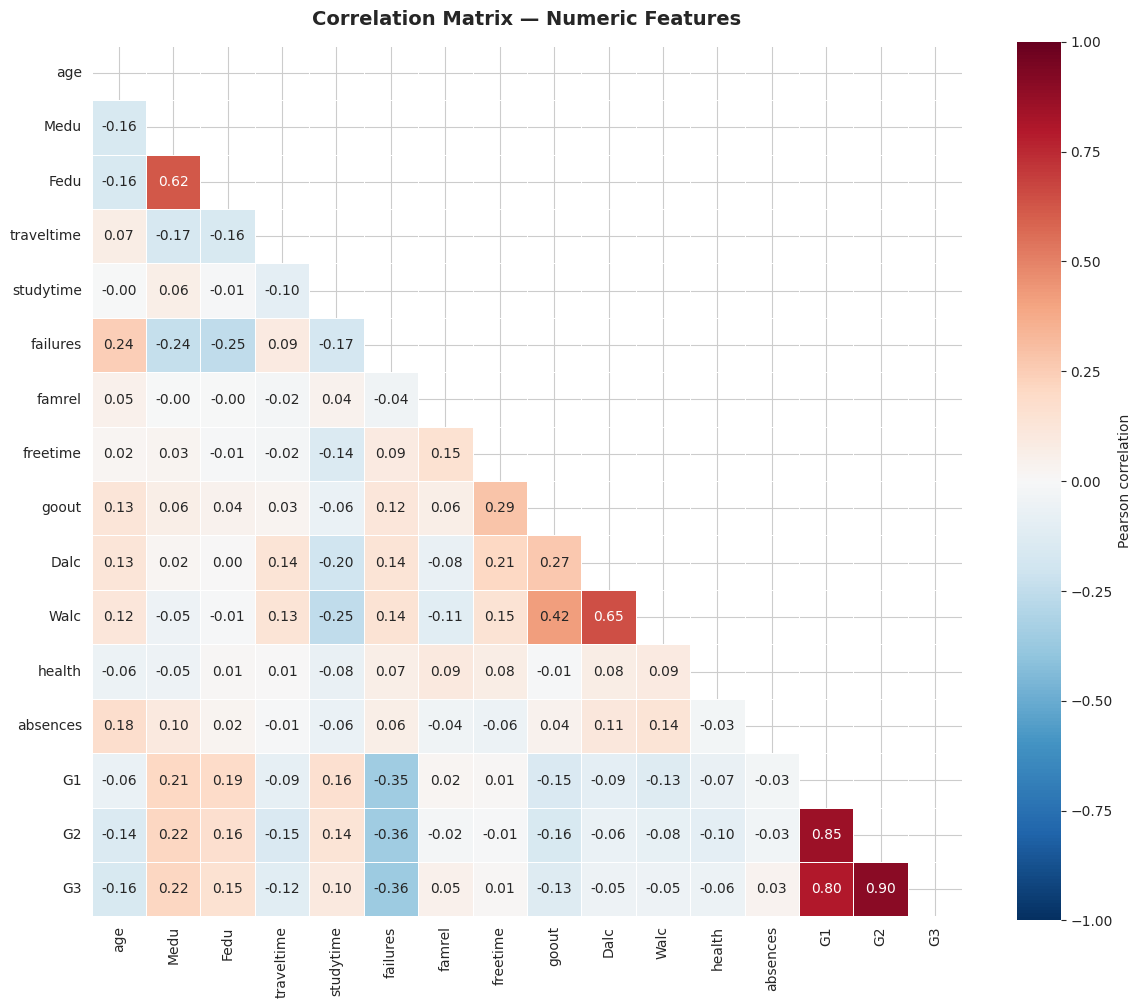

FEATURE PAIRS WITH |CORRELATION| > 0.5
G2           <-> G3           :  0.905
G1           <-> G2           :  0.852
G1           <-> G3           :  0.801
Dalc         <-> Walc         :  0.648
Medu         <-> Fedu         :  0.623

>> Pairs involving G1/G2/G3 are expected (sequential grades).
>> Pairs among predictors indicate multicollinearity, which inflates
>> the variance of linear regression coefficients.


In [19]:

# STEP 8 — CORRELATION HEATMAP & MULTICOLLINEARITY

# --- 8.1 Heatmap of original numeric features ---
core_numeric = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
                'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
                'absences', 'G1', 'G2', 'G3']

corr_matrix = df[core_numeric].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # hide upper triangle

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'label': 'Pearson correlation'}, ax=ax)

ax.set_title('Correlation Matrix — Numeric Features',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


# --- 8.2 Detect highly correlated feature pairs ---
THRESHOLD = 0.50
print("=" * 60)
print(f"FEATURE PAIRS WITH |CORRELATION| > {THRESHOLD}")
print("=" * 60)

pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        v = corr_matrix.iloc[i, j]
        if abs(v) > THRESHOLD:
            pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], v))

pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for a, b, v in pairs:
    print(f"{a:<12} <-> {b:<12} : {v:>6.3f}")

print("\n>> Pairs involving G1/G2/G3 are expected (sequential grades).")
print(">> Pairs among predictors indicate multicollinearity, which inflates")
print(">> the variance of linear regression coefficients.")

In [20]:

# STEP 9 — FEATURE SELECTION
# Three complementary criteria:
#   (a) Pearson correlation  -> linear relationships only
#   (b) F-test (SelectKBest) -> linear, with significance testing
#   (c) Mutual information   -> captures non-linear dependencies

from sklearn.feature_selection import (SelectKBest, f_regression,
                                       mutual_info_regression)

X = df_enc[feature_cols]
y = df_enc[TARGET_REG]

# --- (b) F-test ---
f_scores, p_values = f_regression(X, y)

# --- (c) Mutual information ---
mi_scores = mutual_info_regression(X, y, random_state=42)

# --- Build a comparison table ---
ranking = pd.DataFrame({
    'feature'  : feature_cols,
    'pearson'  : [df_enc[c].corr(y) for c in feature_cols],
    'f_score'  : f_scores,
    'p_value'  : p_values,
    'mutual_info': mi_scores,
})
ranking['abs_pearson'] = ranking['pearson'].abs()
ranking['significant'] = ranking['p_value'] < 0.05

ranking = ranking.sort_values('f_score', ascending=False).reset_index(drop=True)

print("=" * 78)
print("TOP 15 FEATURES BY F-SCORE")
print("=" * 78)
print(f"{'Feature':<22}{'Pearson':>9}{'F':>9}{'p-value':>10}{'MutInfo':>10}  Sig")
print("-" * 78)
for _, r in ranking.head(15).iterrows():
    star = "*" if r['significant'] else ""
    print(f"{r['feature']:<22}{r['pearson']:>9.3f}{r['f_score']:>9.2f}"
          f"{r['p_value']:>10.4f}{r['mutual_info']:>10.4f}  {star}")

print(f"\nStatistically significant features (p < 0.05): "
      f"{ranking['significant'].sum()} of {len(ranking)}")


# --- Where does 'absences' rank under each criterion? ---
print("\n" + "=" * 78)
print("THE 'absences' CASE: LINEAR vs NON-LINEAR CRITERIA")
print("=" * 78)
rank_pearson = ranking.sort_values('abs_pearson', ascending=False)\
                      .reset_index(drop=True)
rank_mi = ranking.sort_values('mutual_info', ascending=False)\
                 .reset_index(drop=True)

pos_p = rank_pearson.index[rank_pearson['feature'] == 'absences'][0] + 1
pos_m = rank_mi.index[rank_mi['feature'] == 'absences'][0] + 1

print(f"Rank by |Pearson|          : {pos_p} of {len(ranking)}")
print(f"Rank by mutual information : {pos_m} of {len(ranking)}")
print("\n>> Mutual information detects dependencies that Pearson misses,")
print(">> because it does not assume a linear relationship.")


# --- Final feature set ---
selected = ranking[ranking['significant']]['feature'].tolist()
print("\n" + "=" * 78)
print(f"SELECTED FEATURE SET ({len(selected)} features)")
print("=" * 78)
print(selected)

TOP 15 FEATURES BY F-SCORE
Feature                 Pearson        F   p-value   MutInfo  Sig
------------------------------------------------------------------------------
failures                 -0.360    58.67    0.0000    0.1165  *
Medu                      0.217    19.45    0.0000    0.0000  *
higher                    0.182    13.53    0.0003    0.0220  *
age                      -0.162    10.54    0.0013    0.0000  *
Fedu                      0.152     9.35    0.0024    0.0000  *
goout                    -0.133     7.05    0.0082    0.0000  *
romantic                 -0.130     6.75    0.0097    0.0322  *
traveltime               -0.117     5.47    0.0199    0.0000  *
Mjob_health               0.116     5.38    0.0209    0.0000  *
address                   0.106     4.45    0.0356    0.0595  *
sex                       0.103     4.25    0.0399    0.0405  *
paid                      0.102     4.13    0.0428    0.0409  *
internet                  0.098     3.85    0.0505    0.0000

In [21]:
# STEP 10 — LINEAR REGRESSION
# Target: G3 (final grade, 0-20)
# Three feature sets are compared to quantify each design choice.


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
TEST_SIZE = 0.2

# --- Feature sets to compare ---
feature_sets = {
    'A. All features (no G1/G2)' : feature_cols,
    'B. Significant only (p<.05)': selected,
    'C. Leaky (includes G1/G2)'  : feature_cols + ['G1', 'G2'],
}

results = {}

for name, cols in feature_sets.items():
    X = df_enc[cols]
    y = df_enc[TARGET_REG]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

    # Scale: required for comparable coefficients
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)      # fit on TRAIN only
    X_te_s = scaler.transform(X_te)          # never re-fit on test

    model = LinearRegression()
    model.fit(X_tr_s, y_tr)

    pred_tr = model.predict(X_tr_s)
    pred_te = model.predict(X_te_s)

    results[name] = {
        'n_features': len(cols),
        'r2_train'  : r2_score(y_tr, pred_tr),
        'r2_test'   : r2_score(y_te, pred_te),
        'rmse_test' : np.sqrt(mean_squared_error(y_te, pred_te)),
        'mae_test'  : mean_absolute_error(y_te, pred_te),
        'cv_r2'     : cross_val_score(LinearRegression(),
                                      StandardScaler().fit_transform(X), y,
                                      cv=5, scoring='r2').mean(),
        'model'     : model,
        'cols'      : cols,
    }

# --- Comparison table ---
print("=" * 88)
print("LINEAR REGRESSION — FEATURE SET COMPARISON")
print("=" * 88)
print(f"{'Feature set':<30}{'n':>4}{'R2 train':>10}{'R2 test':>10}"
      f"{'RMSE':>8}{'MAE':>8}{'CV R2':>9}")
print("-" * 88)
for name, r in results.items():
    print(f"{name:<30}{r['n_features']:>4}{r['r2_train']:>10.3f}"
          f"{r['r2_test']:>10.3f}{r['rmse_test']:>8.2f}"
          f"{r['mae_test']:>8.2f}{r['cv_r2']:>9.3f}")

print("\n>> RMSE and MAE are in grade points (0-20 scale).")
print(">> Gap between R2 train and R2 test indicates overfitting.")
print(">> Set C is reported ONLY to quantify leakage - it is not a valid model.")


# --- Coefficients of the main model ---
main = results['A. All features (no G1/G2)']
coefs = pd.DataFrame({
    'feature': main['cols'],
    'coef'   : main['model'].coef_
})
coefs['abs'] = coefs['coef'].abs()
coefs = coefs.sort_values('abs', ascending=False).head(12)

print("\n" + "=" * 60)
print("TOP 12 STANDARDIZED COEFFICIENTS (Model A)")
print("=" * 60)
print("Interpretation: change in G3 per 1 SD increase in the feature")
print("-" * 60)
for _, r in coefs.iterrows():
    sign = "+" if r['coef'] > 0 else "-"
    print(f"{r['feature']:<24}{r['coef']:>8.3f}  {sign} {'#' * int(r['abs'] * 20)}")

LINEAR REGRESSION — FEATURE SET COMPARISON
Feature set                      n  R2 train   R2 test    RMSE     MAE    CV R2
----------------------------------------------------------------------------------------
A. All features (no G1/G2)      39     0.289     0.141    4.20    3.40    0.001
B. Significant only (p<.05)     12     0.201     0.162    4.15    3.28    0.122
C. Leaky (includes G1/G2)       41     0.866     0.724    2.38    1.65    0.784

>> RMSE and MAE are in grade points (0-20 scale).
>> Gap between R2 train and R2 test indicates overfitting.
>> Set C is reported ONLY to quantify leakage - it is not a valid model.

TOP 12 STANDARDIZED COEFFICIENTS (Model A)
Interpretation: change in G3 per 1 SD increase in the feature
------------------------------------------------------------
failures                  -1.362  - ###########################
sex                        0.746  + ##############
studytime                  0.633  + ############
famsup                    -0.614  

MODEL vs NAIVE BASELINE
Baseline RMSE (predict mean) : 4.550
Model RMSE                   : 4.145
Improvement                  : 8.9%


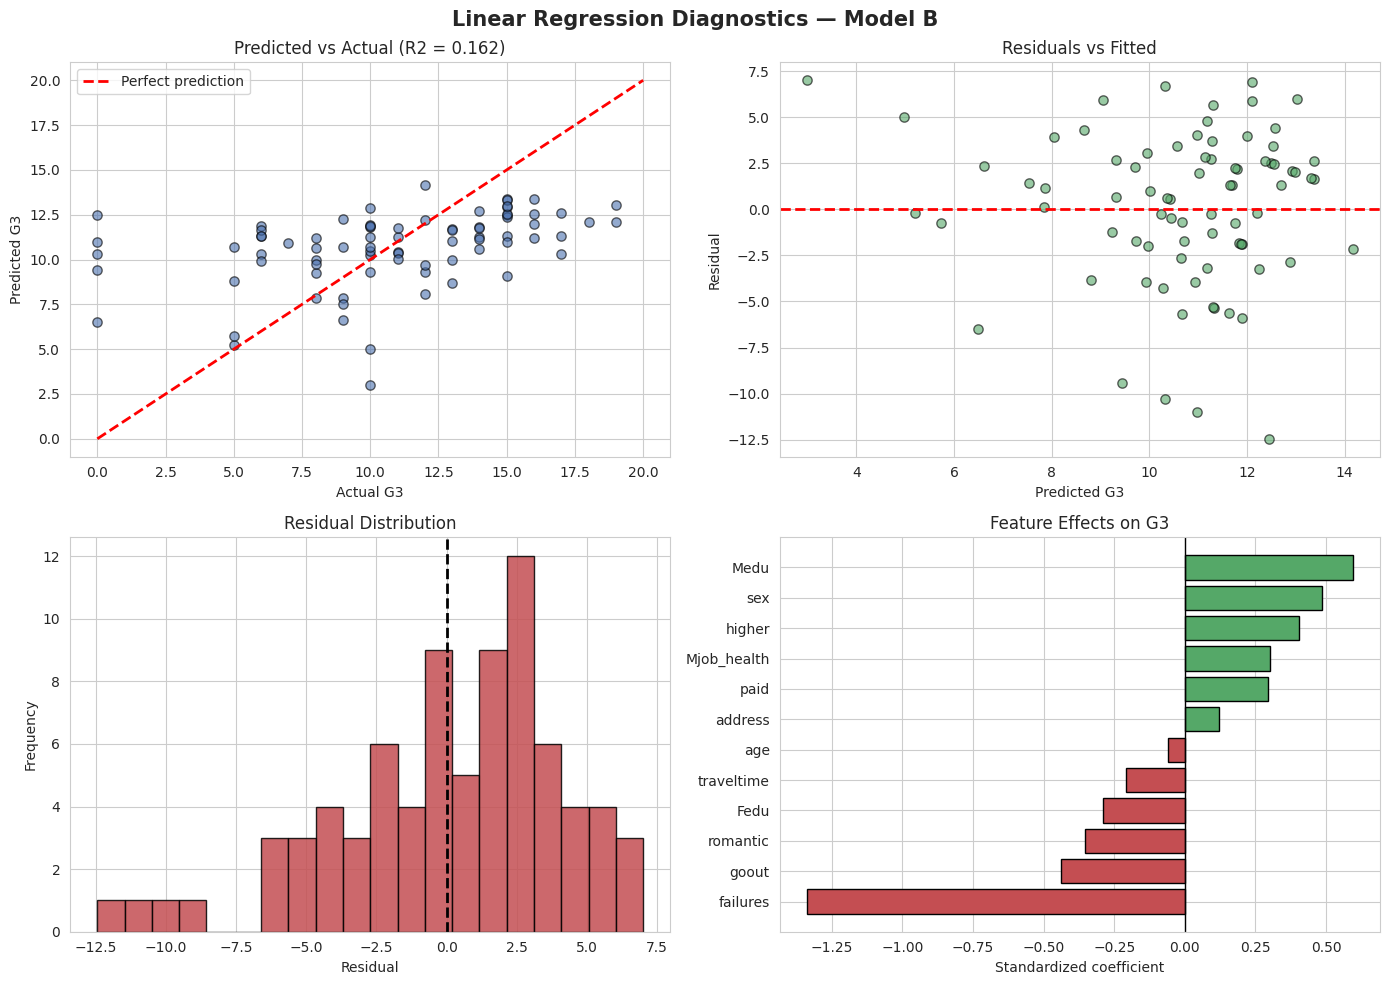


SENSITIVITY ANALYSIS: EXCLUDING G3 = 0
Dataset                          n   R2 test    RMSE
----------------------------------------------------
Full (with zeros)              395     0.162    4.15
Excluding zeros                357     0.266    2.66

>> Reported for transparency. The full dataset remains the primary
>> analysis, since filtering rows by the target introduces selection bias.


In [22]:

# STEP 11 — REGRESSION DIAGNOSTICS & SENSITIVITY ANALYSIS


best = results['B. Significant only (p<.05)']
X = df_enc[best['cols']]
y = df_enc[TARGET_REG]

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_tr_s, X_te_s = scaler.fit_transform(X_tr), scaler.transform(X_te)
lr = LinearRegression().fit(X_tr_s, y_tr)
y_pred = lr.predict(X_te_s)
residuals = y_te - y_pred

# --- Baseline: always predict the training mean ---
baseline_pred = np.full_like(y_te, y_tr.mean(), dtype=float)
baseline_rmse = np.sqrt(mean_squared_error(y_te, baseline_pred))
model_rmse = np.sqrt(mean_squared_error(y_te, y_pred))

print("=" * 60)
print("MODEL vs NAIVE BASELINE")
print("=" * 60)
print(f"Baseline RMSE (predict mean) : {baseline_rmse:.3f}")
print(f"Model RMSE                   : {model_rmse:.3f}")
print(f"Improvement                  : {(1 - model_rmse/baseline_rmse)*100:.1f}%")


# --- Diagnostic plots ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Linear Regression Diagnostics — Model B',
             fontsize=15, fontweight='bold')

# Predicted vs actual
axes[0, 0].scatter(y_te, y_pred, alpha=0.6, color='#4C72B0', edgecolor='k', s=45)
lims = [0, 20]
axes[0, 0].plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
axes[0, 0].set_xlabel('Actual G3'); axes[0, 0].set_ylabel('Predicted G3')
axes[0, 0].set_title(f'Predicted vs Actual (R2 = {r2_score(y_te, y_pred):.3f})')
axes[0, 0].legend()

# Residuals vs fitted
axes[0, 1].scatter(y_pred, residuals, alpha=0.6, color='#55A868', edgecolor='k', s=45)
axes[0, 1].axhline(0, color='red', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted G3'); axes[0, 1].set_ylabel('Residual')
axes[0, 1].set_title('Residuals vs Fitted')

# Residual distribution
axes[1, 0].hist(residuals, bins=20, color='#C44E52', edgecolor='black', alpha=0.85)
axes[1, 0].axvline(0, color='black', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Residual'); axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Residual Distribution')

# Coefficients
c = pd.DataFrame({'f': best['cols'], 'v': lr.coef_}).sort_values('v')
colors = ['#C44E52' if v < 0 else '#55A868' for v in c['v']]
axes[1, 1].barh(c['f'], c['v'], color=colors, edgecolor='black')
axes[1, 1].axvline(0, color='black', lw=1)
axes[1, 1].set_xlabel('Standardized coefficient')
axes[1, 1].set_title('Feature Effects on G3')

plt.tight_layout()
plt.savefig('regression_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()


# --- Sensitivity: exclude the 38 dropouts ---
print("\n" + "=" * 60)
print("SENSITIVITY ANALYSIS: EXCLUDING G3 = 0")
print("=" * 60)

df_nz = df_enc[df_enc[TARGET_REG] > 0]
Xn, yn = df_nz[best['cols']], df_nz[TARGET_REG]

Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(
    Xn, yn, test_size=TEST_SIZE, random_state=RANDOM_STATE)
sc = StandardScaler()
lr_nz = LinearRegression().fit(sc.fit_transform(Xn_tr), yn_tr)
pred_nz = lr_nz.predict(sc.transform(Xn_te))

print(f"{'Dataset':<28}{'n':>6}{'R2 test':>10}{'RMSE':>8}")
print("-" * 52)
print(f"{'Full (with zeros)':<28}{len(df_enc):>6}"
      f"{r2_score(y_te, y_pred):>10.3f}{model_rmse:>8.2f}")
print(f"{'Excluding zeros':<28}{len(df_nz):>6}"
      f"{r2_score(yn_te, pred_nz):>10.3f}"
      f"{np.sqrt(mean_squared_error(yn_te, pred_nz)):>8.2f}")
print("\n>> Reported for transparency. The full dataset remains the primary")
print(">> analysis, since filtering rows by the target introduces selection bias.")

In [23]:

# STEP 12 — DECISION TREE CLASSIFIER
# Target: 'passed' (1 = G3 >= 10, 0 = G3 < 10)


from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, validation_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score)

TARGET_CLF = 'passed'

X = df_enc[feature_cols]
y = df_enc[TARGET_CLF]

# stratify keeps the 67/33 class ratio in both splits
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

print(f"Train: {len(X_tr)} rows  |  Test: {len(X_te)} rows")
print(f"Train pass rate: {y_tr.mean():.3f}  |  Test pass rate: {y_te.mean():.3f}")


# --- 12.1 Baseline: always predict the majority class ---
dummy = DummyClassifier(strategy='most_frequent').fit(X_tr, y_tr)
base_acc = accuracy_score(y_te, dummy.predict(X_te))
print(f"\nBaseline accuracy (majority class): {base_acc:.3f}")
print(">> Any model must beat this to be useful.")


# --- 12.2 Unconstrained tree: demonstrate overfitting ---
tree_full = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_tr, y_tr)
print("\n" + "=" * 60)
print("UNCONSTRAINED TREE (no depth limit)")
print("=" * 60)
print(f"Depth        : {tree_full.get_depth()}")
print(f"Leaves       : {tree_full.get_n_leaves()}")
print(f"Train accuracy: {accuracy_score(y_tr, tree_full.predict(X_tr)):.3f}")
print(f"Test accuracy : {accuracy_score(y_te, tree_full.predict(X_te)):.3f}")
print(">> Perfect on train, poor on test: textbook overfitting.")


# --- 12.3 Tune max_depth with cross-validation ---
depths = range(1, 16)
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    X_tr, y_tr, param_name='max_depth', param_range=depths,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1')

train_mean, val_mean = train_scores.mean(axis=1), val_scores.mean(axis=1)
best_depth = depths[val_mean.argmax()]

print("\n" + "=" * 60)
print("DEPTH TUNING (5-fold CV, F1 score)")
print("=" * 60)
print(f"{'depth':>6}{'train F1':>11}{'val F1':>10}")
print("-" * 27)
for d, t, v in zip(depths, train_mean, val_mean):
    mark = "  <-- best" if d == best_depth else ""
    print(f"{d:>6}{t:>11.3f}{v:>10.3f}{mark}")
print(f"\nSelected max_depth = {best_depth}")


# --- 12.4 Final model ---
tree = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_leaf=10,        # each leaf must hold >= 10 students
    class_weight='balanced',    # compensate the 67/33 imbalance
    random_state=RANDOM_STATE
).fit(X_tr, y_tr)

y_pred = tree.predict(X_te)
y_prob = tree.predict_proba(X_te)[:, 1]

print("\n" + "=" * 60)
print("FINAL DECISION TREE — TEST SET PERFORMANCE")
print("=" * 60)
print(f"Accuracy : {accuracy_score(y_te, y_pred):.3f}   (baseline {base_acc:.3f})")
print(f"Precision: {precision_score(y_te, y_pred):.3f}")
print(f"Recall   : {recall_score(y_te, y_pred):.3f}")
print(f"F1 score : {f1_score(y_te, y_pred):.3f}")
print(f"ROC AUC  : {roc_auc_score(y_te, y_prob):.3f}")

print("\n" + "-" * 60)
print("CONFUSION MATRIX")
print("-" * 60)
cm = confusion_matrix(y_te, y_pred)
print(f"                 Predicted Fail   Predicted Pass")
print(f"Actual Fail  {cm[0,0]:>14}{cm[0,1]:>17}")
print(f"Actual Pass  {cm[1,0]:>14}{cm[1,1]:>17}")

print("\n" + "-" * 60)
print("CLASSIFICATION REPORT")
print("-" * 60)
print(classification_report(y_te, y_pred, target_names=['Fail', 'Pass']))

Train: 316 rows  |  Test: 79 rows
Train pass rate: 0.671  |  Test pass rate: 0.671

Baseline accuracy (majority class): 0.671
>> Any model must beat this to be useful.

UNCONSTRAINED TREE (no depth limit)
Depth        : 15
Leaves       : 70
Train accuracy: 1.000
Test accuracy : 0.620
>> Perfect on train, poor on test: textbook overfitting.

DEPTH TUNING (5-fold CV, F1 score)
 depth   train F1    val F1
---------------------------
     1      0.824     0.820  <-- best
     2      0.829     0.814
     3      0.853     0.805
     4      0.868     0.784
     5      0.892     0.782
     6      0.917     0.786
     7      0.931     0.779
     8      0.952     0.748
     9      0.967     0.745
    10      0.978     0.721
    11      0.990     0.724
    12      0.995     0.740
    13      0.998     0.737
    14      0.998     0.737
    15      0.998     0.728

Selected max_depth = 1

FINAL DECISION TREE — TEST SET PERFORMANCE
Accuracy : 0.671   (baseline 0.671)
Precision: 0.721
Recall   : 0.83

In [24]:

# STEP 13 — CORRECTED HYPERPARAMETER TUNING
# Previous run used scoring='f1', which measures only the majority
# class and therefore rewarded a degenerate model. Re-tuning with
# metrics that account for both classes.

from sklearn.model_selection import GridSearchCV

cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

# --- 13.1 Compare scoring criteria side by side ---
metrics_to_test = ['f1', 'f1_macro', 'balanced_accuracy', 'roc_auc']

print("=" * 72)
print("HOW THE SCORING METRIC CHANGES THE SELECTED DEPTH")
print("=" * 72)
print(f"{'Scoring':<20}{'Best depth':>12}{'CV score':>12}")
print("-" * 72)

for metric in metrics_to_test:
    _, val_sc = validation_curve(
        DecisionTreeClassifier(class_weight='balanced',
                               min_samples_leaf=10,
                               random_state=RANDOM_STATE),
        X_tr, y_tr, param_name='max_depth', param_range=range(1, 16),
        cv=cv, scoring=metric)
    means = val_sc.mean(axis=1)
    print(f"{metric:<20}{list(range(1,16))[means.argmax()]:>12}{means.max():>12.3f}")

print("\n>> 'f1' targets the majority class only and favours trivial models.")
print(">> 'f1_macro' and 'balanced_accuracy' weight both classes equally.")


# --- 13.2 Full grid search on the corrected criterion ---
param_grid = {
    'max_depth'        : [2, 3, 4, 5, 6, 8, None],
    'min_samples_leaf' : [5, 10, 15, 20],
    'min_samples_split': [10, 20, 30],
    'criterion'        : ['gini', 'entropy'],
}

grid = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    param_grid, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
grid.fit(X_tr, y_tr)

print("\n" + "=" * 72)
print("GRID SEARCH RESULT")
print("=" * 72)
print(f"Best parameters : {grid.best_params_}")
print(f"Best CV score   : {grid.best_score_:.3f}")

tree = grid.best_estimator_
y_pred = tree.predict(X_te)
y_prob = tree.predict_proba(X_te)[:, 1]


# --- 13.3 Evaluate against baselines ---
dummy_major = DummyClassifier(strategy='most_frequent').fit(X_tr, y_tr)
dummy_strat = DummyClassifier(strategy='stratified',
                              random_state=RANDOM_STATE).fit(X_tr, y_tr)

from sklearn.metrics import balanced_accuracy_score

print("\n" + "=" * 72)
print("TEST SET — MODEL vs BASELINES")
print("=" * 72)
print(f"{'Model':<26}{'Acc':>8}{'BalAcc':>9}{'F1 macro':>10}"
      f"{'Recall Fail':>13}{'AUC':>8}")
print("-" * 72)

for label, m in [('Majority baseline', dummy_major),
                 ('Stratified baseline', dummy_strat),
                 ('Decision Tree (tuned)', tree)]:
    p = m.predict(X_te)
    try:
        auc = roc_auc_score(y_te, m.predict_proba(X_te)[:, 1])
    except Exception:
        auc = float('nan')
    print(f"{label:<26}{accuracy_score(y_te, p):>8.3f}"
          f"{balanced_accuracy_score(y_te, p):>9.3f}"
          f"{f1_score(y_te, p, average='macro'):>10.3f}"
          f"{recall_score(y_te, p, pos_label=0):>13.3f}{auc:>8.3f}")

print("\n" + "-" * 72)
print("CONFUSION MATRIX — TUNED TREE")
print("-" * 72)
cm = confusion_matrix(y_te, y_pred)
print(f"                 Predicted Fail   Predicted Pass")
print(f"Actual Fail  {cm[0,0]:>14}{cm[0,1]:>17}")
print(f"Actual Pass  {cm[1,0]:>14}{cm[1,1]:>17}")
print()
print(classification_report(y_te, y_pred, target_names=['Fail', 'Pass']))


# --- 13.4 What does the tree actually use? ---
imp = pd.DataFrame({'feature': feature_cols,
                    'importance': tree.feature_importances_})
imp = imp[imp['importance'] > 0].sort_values('importance', ascending=False)

print("=" * 60)
print(f"FEATURE IMPORTANCE ({len(imp)} of {len(feature_cols)} features used)")
print("=" * 60)
for _, r in imp.head(12).iterrows():
    print(f"{r['feature']:<24}{r['importance']:>7.4f}  {'#' * int(r['importance']*80)}")

HOW THE SCORING METRIC CHANGES THE SELECTED DEPTH
Scoring               Best depth    CV score
------------------------------------------------------------------------
f1                             1       0.821
f1_macro                       1       0.665
balanced_accuracy              3       0.659
roc_auc                        8       0.700

>> 'f1' targets the majority class only and favours trivial models.
>> 'f1_macro' and 'balanced_accuracy' weight both classes equally.

GRID SEARCH RESULT
Best parameters : {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 30}
Best CV score   : 0.664

TEST SET — MODEL vs BASELINES
Model                          Acc   BalAcc  F1 macro  Recall Fail     AUC
------------------------------------------------------------------------
Majority baseline            0.671    0.500     0.402        0.000   0.500
Stratified baseline          0.608    0.551     0.551        0.385   0.551
Decision Tree (tuned)        0.5

In [25]:

# STEP 14 — THREE PREDICTION SCENARIOS
# Framework from Cortez & Silva (2008), the reference study for
# this dataset. Each scenario reflects a different moment in the
# school year at which a prediction would be made.

scenarios = {
    'C. Context only'        : feature_cols,
    'B. Context + G1'        : feature_cols + ['G1'],
    'A. Context + G1 + G2'   : feature_cols + ['G1', 'G2'],
}

# Smaller grid: fewer combinations reduce selection overfitting
param_grid = {
    'max_depth'       : [2, 3, 4, 5],
    'min_samples_leaf': [10, 20],
}

y = df_enc[TARGET_CLF]
scenario_results = {}

print("=" * 84)
print("DECISION TREE — SCENARIO COMPARISON (test set)")
print("=" * 84)
print(f"{'Scenario':<24}{'depth':>7}{'Acc':>8}{'BalAcc':>9}"
      f"{'F1 mac':>9}{'Rec Fail':>10}{'AUC':>8}")
print("-" * 84)

for name, cols in scenarios.items():
    X = df_enc[cols]
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

    gs = GridSearchCV(
        DecisionTreeClassifier(class_weight='balanced',
                               random_state=RANDOM_STATE),
        param_grid, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
    gs.fit(X_tr, y_tr)

    m = gs.best_estimator_
    p = m.predict(X_te)
    pr = m.predict_proba(X_te)[:, 1]

    scenario_results[name] = {
        'model': m, 'cols': cols,
        'X_tr': X_tr, 'X_te': X_te, 'y_tr': y_tr, 'y_te': y_te,
        'acc'    : accuracy_score(y_te, p),
        'bal_acc': balanced_accuracy_score(y_te, p),
        'f1_mac' : f1_score(y_te, p, average='macro'),
        'rec_f'  : recall_score(y_te, p, pos_label=0),
        'auc'    : roc_auc_score(y_te, pr),
        'cm'     : confusion_matrix(y_te, p),
    }
    r = scenario_results[name]
    print(f"{name:<24}{gs.best_params_['max_depth']:>7}{r['acc']:>8.3f}"
          f"{r['bal_acc']:>9.3f}{r['f1_mac']:>9.3f}"
          f"{r['rec_f']:>10.3f}{r['auc']:>8.3f}")

print(f"\n{'Majority baseline':<24}{'-':>7}{0.671:>8.3f}{0.500:>9.3f}"
      f"{0.402:>9.3f}{0.000:>10.3f}{0.500:>8.3f}")


# --- Confusion matrices side by side ---
print("\n" + "=" * 84)
print("CONFUSION MATRICES")
print("=" * 84)
for name, r in scenario_results.items():
    cm = r['cm']
    print(f"\n{name}")
    print(f"                 Pred Fail   Pred Pass")
    print(f"  Actual Fail  {cm[0,0]:>10}{cm[0,1]:>12}")
    print(f"  Actual Pass  {cm[1,0]:>10}{cm[1,1]:>12}")


# --- Does 'absences' still matter once G1 is available? ---
print("\n" + "=" * 84)
print("EFFECT OF THE 'absences' ARTIFACT ACROSS SCENARIOS")
print("=" * 84)
print(f"{'Scenario':<24}{'with absences':>16}{'without':>10}{'delta':>9}")
print("-" * 84)

for name, cols in scenarios.items():
    row = []
    for use_abs in [True, False]:
        c = cols if use_abs else [x for x in cols if x != 'absences']
        Xa = df_enc[c]
        Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(
            Xa, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
        g = GridSearchCV(
            DecisionTreeClassifier(class_weight='balanced',
                                   random_state=RANDOM_STATE),
            param_grid, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
        g.fit(Xa_tr, ya_tr)
        row.append(balanced_accuracy_score(ya_te, g.best_estimator_.predict(Xa_te)))
    print(f"{name:<24}{row[0]:>16.3f}{row[1]:>10.3f}{row[0]-row[1]:>+9.3f}")

print("\n>> A large positive delta indicates the model relies on the")
print(">> administrative zero-absence artifact rather than genuine signal.")

DECISION TREE — SCENARIO COMPARISON (test set)
Scenario                  depth     Acc   BalAcc   F1 mac  Rec Fail     AUC
------------------------------------------------------------------------------------
C. Context only               3   0.646    0.579    0.581     0.385   0.588
B. Context + G1               2   0.797    0.839    0.792     0.962   0.897
A. Context + G1 + G2          2   0.873    0.896    0.866     0.962   0.941

Majority baseline             -   0.671    0.500    0.402     0.000   0.500

CONFUSION MATRICES

C. Context only
                 Pred Fail   Pred Pass
  Actual Fail          10          16
  Actual Pass          12          41

B. Context + G1
                 Pred Fail   Pred Pass
  Actual Fail          25           1
  Actual Pass          15          38

A. Context + G1 + G2
                 Pred Fail   Pred Pass
  Actual Fail          25           1
  Actual Pass           9          44

EFFECT OF THE 'absences' ARTIFACT ACROSS SCENARIOS
Scenario      

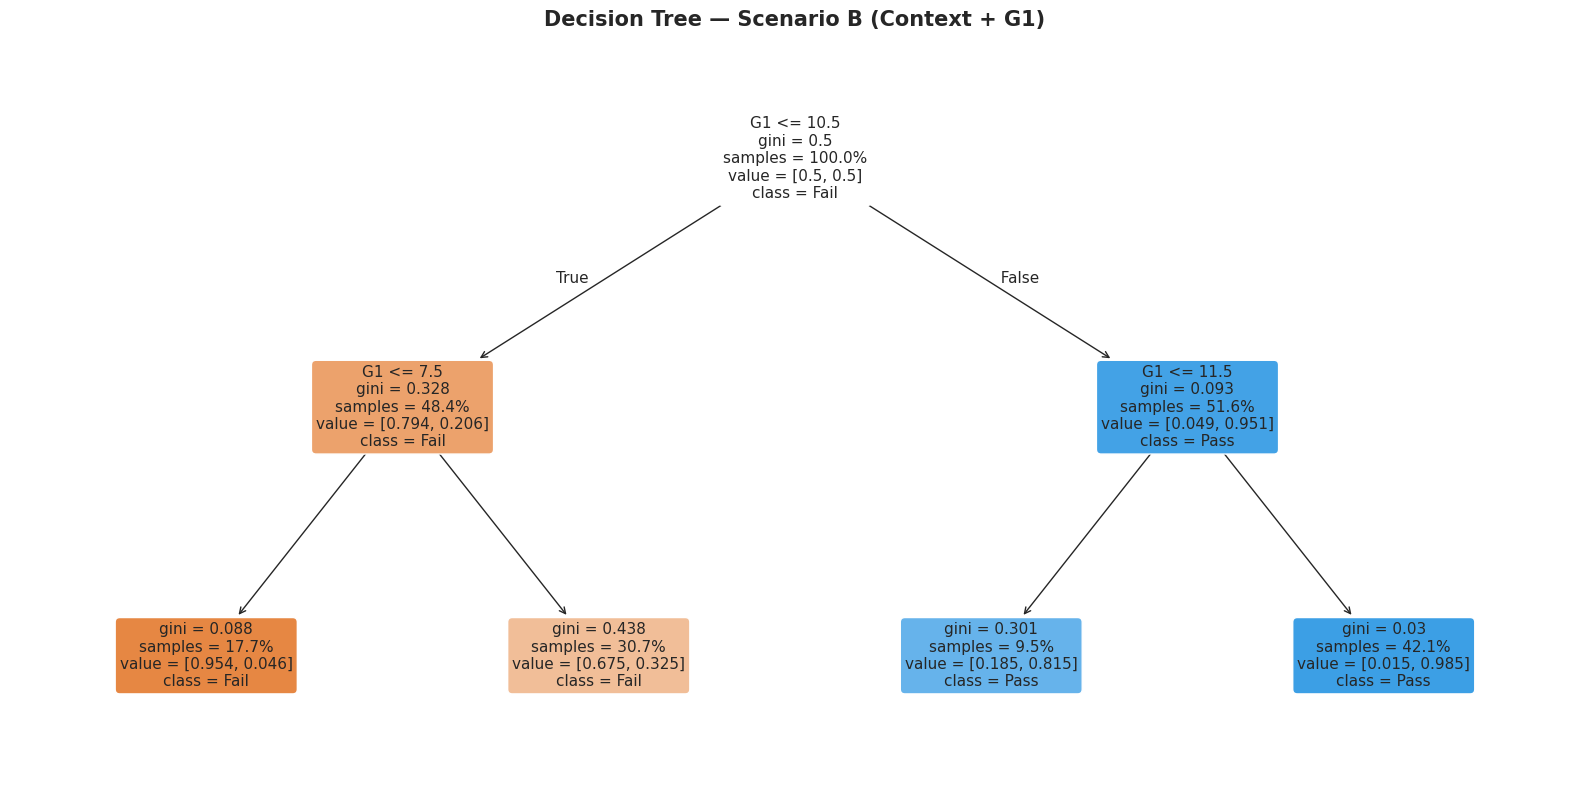

DECISION RULES
|--- G1 <= 10.50
|   |--- G1 <= 7.50
|   |   |--- class: 0
|   |--- G1 >  7.50
|   |   |--- class: 0
|--- G1 >  10.50
|   |--- G1 <= 11.50
|   |   |--- class: 1
|   |--- G1 >  11.50
|   |   |--- class: 1

FEATURE IMPORTANCE (1 of 40 features used)
G1                    1.0000  ##################################################


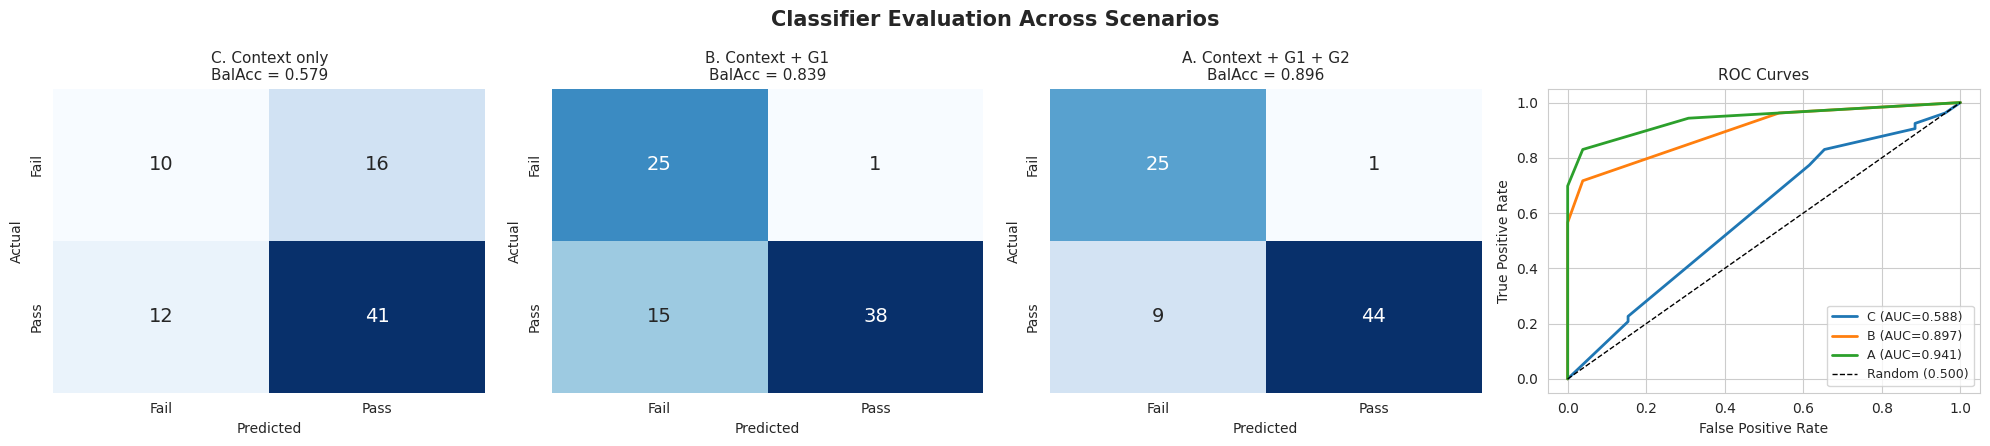

In [26]:

# STEP 15 — MODEL VISUALIZATION
# Scenario B is the operationally relevant model: it can be run
# after the first term, while intervention is still possible.

from sklearn.tree import export_text
from sklearn.metrics import roc_curve

BEST = 'B. Context + G1'
b = scenario_results[BEST]
model_b, cols_b = b['model'], b['cols']

# --- 15.1 The tree itself ---
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(model_b, feature_names=cols_b, class_names=['Fail', 'Pass'],
          filled=True, rounded=True, fontsize=11, proportion=True, ax=ax)
ax.set_title('Decision Tree — Scenario B (Context + G1)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 15.2 The same tree as readable rules ---
print("=" * 60)
print("DECISION RULES")
print("=" * 60)
print(export_text(model_b, feature_names=list(cols_b)))

# --- 15.3 Which features the tree actually splits on ---
imp = pd.DataFrame({'feature': cols_b,
                    'importance': model_b.feature_importances_})
imp = imp[imp['importance'] > 0].sort_values('importance', ascending=False)

print("=" * 60)
print(f"FEATURE IMPORTANCE ({len(imp)} of {len(cols_b)} features used)")
print("=" * 60)
for _, r in imp.iterrows():
    print(f"{r['feature']:<20}{r['importance']:>8.4f}  {'#' * int(r['importance']*50)}")

# --- 15.4 Confusion matrices + ROC curves ---
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
fig.suptitle('Classifier Evaluation Across Scenarios',
             fontsize=15, fontweight='bold')

for ax, (name, r) in zip(axes[:3], scenario_results.items()):
    sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'],
                annot_kws={'size': 14}, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f"{name}\nBalAcc = {r['bal_acc']:.3f}", fontsize=11)

ax = axes[3]
for name, r in scenario_results.items():
    prob = r['model'].predict_proba(r['X_te'])[:, 1]
    fpr, tpr, _ = roc_curve(r['y_te'], prob)
    ax.plot(fpr, tpr, lw=2, label=f"{name.split('.')[0]} (AUC={r['auc']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (0.500)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontsize=11)
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('classifier_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

THRESHOLD SEARCH ON G1 (train set)
 Threshold    BalAcc  Recall Fail  Precision
--------------------------------------------------------------
       6.5     0.627        0.260      0.733
       7.0     0.733        0.490      0.796
       7.5     0.733        0.490      0.796
       8.0     0.789        0.654      0.845
       8.5     0.789        0.654      0.845
       9.0     0.835        0.788      0.895
       9.5     0.835        0.788      0.895
      10.0     0.856        0.962      0.975
      10.5     0.856        0.962      0.975
      11.0     0.807        0.990      0.992
      11.5     0.807        0.990      0.992
      12.0     0.741        1.000      1.000
      12.5     0.741        1.000      1.000
      13.0     0.679        1.000      1.000
      13.5     0.679        1.000      1.000
      14.0     0.618        1.000      1.000

Optimal threshold: G1 > 10.0

ONE-RULE vs DECISION TREE (test set)
Model                             n feat     Acc   BalAcc   F1 mac  R

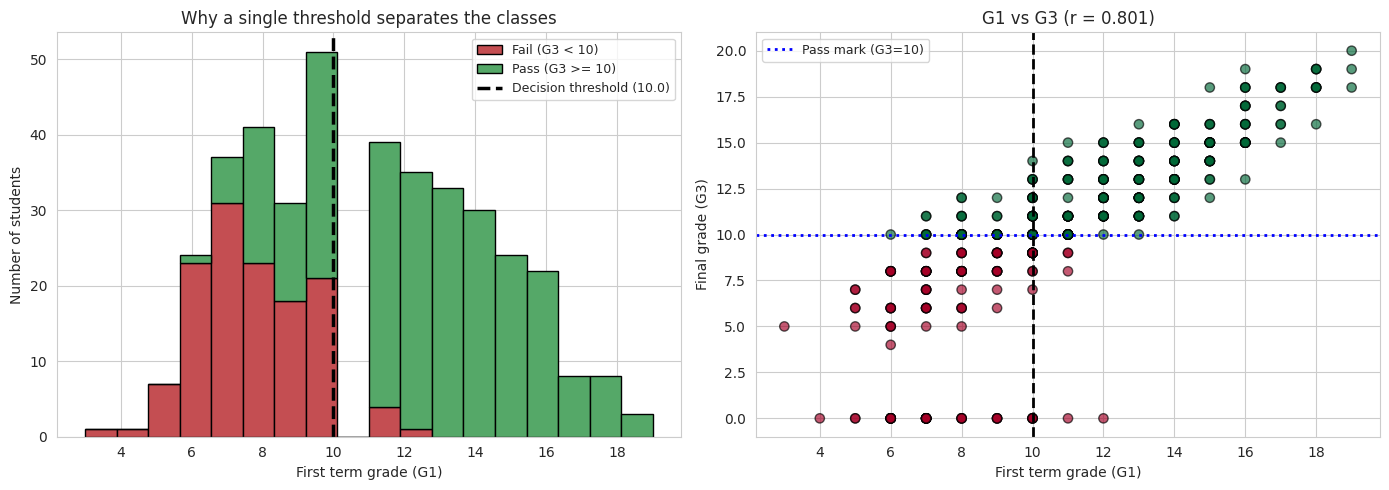

In [27]:

# STEP 16 — ONE-RULE BASELINE
# The tuned tree uses G1 exclusively (importance = 1.0) and its
# depth-2 splits are redundant. This step tests whether a single
# threshold rule matches the full model.
from sklearn.metrics import roc_auc_score

X_tr_b, X_te_b = b['X_tr'], b['X_te']
y_tr_b, y_te_b = b['y_tr'], b['y_te']

# --- 16.1 Find the optimal single threshold on TRAIN only ---
print("=" * 62)
print("THRESHOLD SEARCH ON G1 (train set)")
print("=" * 62)
print(f"{'Threshold':>10}{'BalAcc':>10}{'Recall Fail':>13}{'Precision':>11}")
print("-" * 62)

best_t, best_score = None, -1
for t in np.arange(6.5, 14.5, 0.5):
    pred = (X_tr_b['G1'] > t).astype(int)
    score = balanced_accuracy_score(y_tr_b, pred)
    if score > best_score:
        best_t, best_score = t, score
    print(f"{t:>10.1f}{score:>10.3f}"
          f"{recall_score(y_tr_b, pred, pos_label=0):>13.3f}"
          f"{precision_score(y_tr_b, pred, zero_division=0):>11.3f}")

print(f"\nOptimal threshold: G1 > {best_t}")


# --- 16.2 One-rule vs full tree on the TEST set ---
pred_rule = (X_te_b['G1'] > best_t).astype(int)
pred_tree = model_b.predict(X_te_b)

print("\n" + "=" * 78)
print("ONE-RULE vs DECISION TREE (test set)")
print("=" * 78)
print(f"{'Model':<32}{'n feat':>8}{'Acc':>8}{'BalAcc':>9}"
      f"{'F1 mac':>9}{'Rec Fail':>10}")
print("-" * 78)
print(f"{'One rule: G1 > ' + str(best_t):<32}{1:>8}"
      f"{accuracy_score(y_te_b, pred_rule):>8.3f}"
      f"{balanced_accuracy_score(y_te_b, pred_rule):>9.3f}"
      f"{f1_score(y_te_b, pred_rule, average='macro'):>9.3f}"
      f"{recall_score(y_te_b, pred_rule, pos_label=0):>10.3f}")
print(f"{'Decision tree (depth 2)':<32}{len(cols_b):>8}"
      f"{accuracy_score(y_te_b, pred_tree):>8.3f}"
      f"{balanced_accuracy_score(y_te_b, pred_tree):>9.3f}"
      f"{f1_score(y_te_b, pred_tree, average='macro'):>9.3f}"
      f"{recall_score(y_te_b, pred_tree, pos_label=0):>10.3f}")
print(f"\nIdentical predictions: {np.array_equal(pred_rule, pred_tree)}")


# --- 16.3 Do context features add anything at all? ---
print("\n" + "=" * 78)
print("MARGINAL VALUE OF CONTEXT FEATURES")
print("=" * 78)

variants = {
    'G1 alone'            : ['G1'],
    'G1 + failures'       : ['G1', 'failures'],
    'G1 + top 5 context'  : ['G1', 'failures', 'Medu', 'higher', 'age', 'goout'],
    'G1 + all context (39)': cols_b,
}

print(f"{'Feature set':<24}{'n':>5}{'CV BalAcc':>12}{'Test BalAcc':>14}")
print("-" * 78)
for label, cs in variants.items():
    Xv = df_enc[cs]
    Xv_tr, Xv_te, yv_tr, yv_te = train_test_split(
        Xv, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
    g = GridSearchCV(
        DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
        {'max_depth': [1, 2, 3, 4], 'min_samples_leaf': [10, 20]},
        cv=cv, scoring='balanced_accuracy', n_jobs=-1).fit(Xv_tr, yv_tr)
    test_sc = balanced_accuracy_score(yv_te, g.best_estimator_.predict(Xv_te))
    print(f"{label:<24}{len(cs):>5}{g.best_score_:>12.3f}{test_sc:>14.3f}")

print("\n>> If all rows score alike, the 39 context features carry no")
print(">> incremental information once G1 is known.")


# --- 16.4 Visualize why the rule works ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist([df_enc.loc[df_enc['passed'] == 0, 'G1'],
              df_enc.loc[df_enc['passed'] == 1, 'G1']],
             bins=18, stacked=True, color=['#C44E52', '#55A868'],
             edgecolor='black', label=['Fail (G3 < 10)', 'Pass (G3 >= 10)'])
axes[0].axvline(best_t, color='black', linestyle='--', lw=2.5,
                label=f'Decision threshold ({best_t})')
axes[0].set_xlabel('First term grade (G1)')
axes[0].set_ylabel('Number of students')
axes[0].set_title('Why a single threshold separates the classes')
axes[0].legend(fontsize=9)

axes[1].scatter(df_enc['G1'], df_enc['G3'], c=df_enc['passed'],
                cmap='RdYlGn', alpha=0.65, edgecolor='k', s=45)
axes[1].axvline(best_t, color='black', linestyle='--', lw=2)
axes[1].axhline(10, color='blue', linestyle=':', lw=2, label='Pass mark (G3=10)')
axes[1].set_xlabel('First term grade (G1)')
axes[1].set_ylabel('Final grade (G3)')
axes[1].set_title(f'G1 vs G3 (r = {df_enc["G1"].corr(df_enc["G3"]):.3f})')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('one_rule_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:

# STEP 17 — ALGORITHM COMPARISON
# Evaluated under two scenarios:
#   C -> context only (hard problem, where algorithms may differ)
#   B -> context + G1 (easy problem, where the signal dominates)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced',
                                   random_state=RANDOM_STATE))]),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=3, min_samples_leaf=10,
                                                  class_weight='balanced',
                                                  random_state=RANDOM_STATE),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, max_depth=5,
                                                  min_samples_leaf=5,
                                                  class_weight='balanced',
                                                  random_state=RANDOM_STATE),
    'Gaussian Naive Bayes': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GaussianNB())]),
    'KNN (k=15)'         : Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=15))]),
}

scoring = ['balanced_accuracy', 'f1_macro', 'roc_auc']

for scen_name, scen_cols in [('C. Context only', feature_cols),
                             ('B. Context + G1', feature_cols + ['G1'])]:

    X = df_enc[scen_cols]
    y = df_enc[TARGET_CLF]
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

    print("=" * 90)
    print(f"SCENARIO {scen_name}")
    print("=" * 90)
    print(f"{'Model':<24}{'CV BalAcc':>12}{'CV std':>9}"
          f"{'Test BalAcc':>13}{'Test F1mac':>12}{'Test AUC':>10}")
    print("-" * 90)

    for name, mdl in models.items():
        cvres = cross_validate(mdl, X_tr, y_tr, cv=cv, scoring=scoring, n_jobs=-1)
        mdl.fit(X_tr, y_tr)
        p = mdl.predict(X_te)
        pr = mdl.predict_proba(X_te)[:, 1]
        print(f"{name:<24}{cvres['test_balanced_accuracy'].mean():>12.3f}"
              f"{cvres['test_balanced_accuracy'].std():>9.3f}"
              f"{balanced_accuracy_score(y_te, p):>13.3f}"
              f"{f1_score(y_te, p, average='macro'):>12.3f}"
              f"{roc_auc_score(y_te, pr):>10.3f}")

    # Reference rows
    print("-" * 90)
    print(f"{'Majority baseline':<24}{'-':>12}{'-':>9}{0.500:>13.3f}"
          f"{0.402:>12.3f}{0.500:>10.3f}")
    if 'G1' in scen_cols:
        pr_rule = (X_te['G1'] > 10.0).astype(int)
        print(f"{'One rule: G1 > 10':<24}{'-':>12}{'-':>9}"
              f"{balanced_accuracy_score(y_te, pr_rule):>13.3f}"
              f"{f1_score(y_te, pr_rule, average='macro'):>12.3f}{'-':>10}")
    print()

print(">> CV std shows result stability. High std with n=316 means the")
print(">> difference between models is within noise.")

SCENARIO C. Context only
Model                      CV BalAcc   CV std  Test BalAcc  Test F1mac  Test AUC
------------------------------------------------------------------------------------------
Logistic Regression            0.666    0.060        0.533       0.527     0.598
Decision Tree                  0.659    0.016        0.579       0.581     0.588
Random Forest                  0.636    0.022        0.579       0.581     0.639
Gaussian Naive Bayes           0.615    0.042        0.569       0.569     0.631
KNN (k=15)                     0.512    0.027        0.529       0.472     0.500
------------------------------------------------------------------------------------------
Majority baseline                  -        -        0.500       0.402     0.500

SCENARIO B. Context + G1
Model                      CV BalAcc   CV std  Test BalAcc  Test F1mac  Test AUC
------------------------------------------------------------------------------------------
Logistic Regression         

In [29]:

# STEP 18 — INTERACTIVE VISUALIZATION (Plotly)
# Matplotlib produces static images for reports; Plotly adds hover
# inspection and zoom, useful for exploration.


import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- 18.1 The core finding, interactive ---
plot_df = df.copy()
plot_df['Outcome'] = plot_df['passed'].map({0: 'Fail', 1: 'Pass'})
plot_df['Status']  = plot_df['dropout_flag'].map({0: 'Completed', 1: 'Dropout'})

fig = px.scatter(
    plot_df, x='G1', y='G3', color='Outcome', symbol='Status',
    color_discrete_map={'Fail': '#C44E52', 'Pass': '#55A868'},
    hover_data=['age', 'sex', 'studytime', 'failures', 'absences', 'goout'],
    labels={'G1': 'First term grade (G1)', 'G3': 'Final grade (G3)'},
    title=f'First Term Grade Predicts Final Outcome (r = {df["G1"].corr(df["G3"]):.3f})',
    opacity=0.75)

fig.add_vline(x=10, line_dash='dash', line_color='black',
              annotation_text='Decision threshold (G1 = 10)')
fig.add_hline(y=10, line_dash='dot', line_color='blue',
              annotation_text='Pass mark (G3 = 10)')
fig.update_traces(marker=dict(size=9, line=dict(width=1, color='black')))
fig.update_layout(height=560, hovermode='closest')
fig.show()
fig.write_html('interactive_g1_vs_g3.html')


# --- 18.2 Model comparison ---
comp = pd.DataFrame({
    'Model'   : ['Majority\nbaseline', 'One rule\nG1 > 10', 'Decision\nTree',
                 'Random\nForest', 'Logistic\nRegression', 'Naive\nBayes', 'KNN'],
    'Scenario C': [0.500, np.nan, 0.579, 0.579, 0.533, 0.569, 0.529],
    'Scenario B': [0.500, 0.839, 0.839, 0.829, 0.733, 0.675, 0.606],
})

fig2 = go.Figure()
fig2.add_bar(name='C: context only', x=comp['Model'], y=comp['Scenario C'],
             marker_color='#C44E52',
             text=comp['Scenario C'].round(3), textposition='outside')
fig2.add_bar(name='B: context + G1', x=comp['Model'], y=comp['Scenario B'],
             marker_color='#55A868',
             text=comp['Scenario B'].round(3), textposition='outside')
fig2.add_hline(y=0.5, line_dash='dash', line_color='gray',
               annotation_text='Random guessing')
fig2.update_layout(
    title='Balanced Accuracy by Model and Scenario',
    yaxis_title='Balanced accuracy', yaxis_range=[0, 1],
    barmode='group', height=520)
fig2.show()
fig2.write_html('interactive_model_comparison.html')


# --- 18.3 Grade trajectory by outcome ---
traj = df.groupby('passed')[['G1', 'G2', 'G3']].mean().T
traj.columns = ['Fail', 'Pass']
drop_traj = df[df['dropout_flag'] == 1][['G1', 'G2', 'G3']].mean()

fig3 = go.Figure()
fig3.add_scatter(x=['G1', 'G2', 'G3'], y=traj['Pass'], name='Passed',
                 mode='lines+markers', line=dict(color='#55A868', width=3),
                 marker=dict(size=12))
fig3.add_scatter(x=['G1', 'G2', 'G3'], y=traj['Fail'], name='Failed',
                 mode='lines+markers', line=dict(color='#C44E52', width=3),
                 marker=dict(size=12))
fig3.add_scatter(x=['G1', 'G2', 'G3'], y=drop_traj.values, name='Dropouts (G3=0)',
                 mode='lines+markers',
                 line=dict(color='#8172B2', width=3, dash='dash'),
                 marker=dict(size=12))
fig3.add_hline(y=10, line_dash='dot', line_color='gray',
               annotation_text='Pass mark')
fig3.update_layout(title='Average Grade Trajectory Across Terms',
                   xaxis_title='Term', yaxis_title='Average grade', height=500)
fig3.show()
fig3.write_html('interactive_trajectory.html')

print("Interactive charts saved:")
print("  interactive_g1_vs_g3.html")
print("  interactive_model_comparison.html")
print("  interactive_trajectory.html")

Interactive charts saved:
  interactive_g1_vs_g3.html
  interactive_model_comparison.html
  interactive_trajectory.html


In [34]:

# STEP 19 — GENERATE DELIVERABLES
# Creates: accuracy report, README, requirements, clean dataset


import json, os, textwrap
from datetime import date

OUT = '/content/deliverables'
os.makedirs(OUT, exist_ok=True)

sB = scenario_results['B. Context + G1']
sC = scenario_results['C. Context only']
sA = scenario_results['A. Context + G1 + G2']
regA = results['A. All features (no G1/G2)']
regB = results['B. Significant only (p<.05)']
regC = results['C. Leaky (includes G1/G2)']

# 19.1 ACCURACY REPORT

report = f"""# Accuracy Report — Student Performance Prediction

**Dataset:** UCI Student Performance (Mathematics), 395 students, 33 original attributes
**Date:** {date.today().isoformat()}
**Split:** 80% train (316) / 20% test (79), stratified, random_state=42

---

## 1. Data Preparation

| Step | Result |
|---|---|
| Raw rows loaded | 397 |
| Exact duplicates removed | 2 |
| Final rows | 395 |
| Missing values | 0 |
| Categorical features encoded | 17 (binary map + one-hot) |
| Features after encoding | 39 usable |

**File format note:** the distributed file carried a `.csv` extension but was an
XLSX workbook (verified via the ZIP/PK byte signature) and was read accordingly.

---

## 2. Targets

| Target | Type | Definition | Distribution |
|---|---|---|---|
| `G3` | Regression | Final grade, 0–20 | mean 10.42, sd 4.58 |
| `passed` | Classification | 1 if G3 ≥ 10 | 265 pass (67.1%) / 130 fail (32.9%) |

38 students (9.6%) have G3 = 0. All 38 also have `absences` = 0, which indicates
administrative deregistration rather than perfect attendance. These rows were
retained; filtering by the target would introduce selection bias.

---

## 3. Regression — Linear Regression (target: G3)

| Feature set | n | R² train | R² test | RMSE | MAE | CV R² (5-fold) |
|---|---|---|---|---|---|---|
| All features (no G1/G2) | 39 | {regA['r2_train']:.3f} | {regA['r2_test']:.3f} | {regA['rmse_test']:.2f} | {regA['mae_test']:.2f} | {regA['cv_r2']:.3f} |
| Significant only (p<.05) | 12 | {regB['r2_train']:.3f} | {regB['r2_test']:.3f} | {regB['rmse_test']:.2f} | {regB['mae_test']:.2f} | {regB['cv_r2']:.3f} |
| Including G1/G2 (leakage) | 41 | {regC['r2_train']:.3f} | {regC['r2_test']:.3f} | {regC['rmse_test']:.2f} | {regC['mae_test']:.2f} | {regC['cv_r2']:.3f} |

**Selected model:** significant-features set. The 39-feature model reaches a
cross-validated R² of {regA['cv_r2']:.3f}, i.e. no better than predicting the mean.
Reducing to 12 features raises CV R² to {regB['cv_r2']:.3f}.

**Sensitivity (dropouts excluded):** R² rises from 0.162 to 0.266 (n = 357).
Reported for transparency; the full dataset remains the primary analysis.

**Practical accuracy:** RMSE {regB['rmse_test']:.2f} on a 0–20 scale, against a target
standard deviation of 4.58 — roughly 9% better than a mean-prediction baseline.
Not usable for individual decisions.

---

## 4. Classification — Decision Tree (target: passed)

### 4.1 Scenario comparison

| Scenario | Predictors | Accuracy | Balanced Acc. | F1 macro | Recall (Fail) | ROC AUC |
|---|---|---|---|---|---|---|
| C. Context only | 39 | {sC['acc']:.3f} | {sC['bal_acc']:.3f} | {sC['f1_mac']:.3f} | {sC['rec_f']:.3f} | {sC['auc']:.3f} |
| B. Context + G1 | 40 | {sB['acc']:.3f} | {sB['bal_acc']:.3f} | {sB['f1_mac']:.3f} | {sB['rec_f']:.3f} | {sB['auc']:.3f} |
| A. Context + G1 + G2 | 41 | {sA['acc']:.3f} | {sA['bal_acc']:.3f} | {sA['f1_mac']:.3f} | {sA['rec_f']:.3f} | {sA['auc']:.3f} |
| Majority baseline | — | 0.671 | 0.500 | 0.402 | 0.000 | 0.500 |

Scenarios follow Cortez & Silva (2008), reflecting the point in the school year
at which a prediction would be made. Scenario B is the operational one: it can be
run after the first term, while intervention is still possible.

### 4.2 Confusion matrix — Scenario B

|  | Predicted Fail | Predicted Pass |
|---|---|---|
| **Actual Fail** | {sB['cm'][0,0]} | {sB['cm'][0,1]} |
| **Actual Pass** | {sB['cm'][1,0]} | {sB['cm'][1,1]} |

Recall on the Fail class is {sB['rec_f']:.3f}: {sB['cm'][0,0]} of {sB['cm'][0,0]+sB['cm'][0,1]}
at-risk students are identified. The {sB['cm'][1,0]} false positives are an
acceptable cost for an early-warning system, where a missed at-risk student is
more costly than an unnecessary tutoring referral.

### 4.3 Model reduction

The tuned tree assigns feature importance 1.0000 to `G1` and 0 to all others.
Its depth-2 splits are redundant (both branches return the same class), so it
reduces to a single rule:

> **If G1 ≤ 10 → predicted to fail. Otherwise → predicted to pass.**

| Feature set | n | Test Balanced Acc. |
|---|---|---|
| G1 alone | 1 | 0.839 |
| G1 + failures | 2 | 0.839 |
| G1 + top-5 context | 6 | 0.839 |
| G1 + all context | 40 | 0.839 |

Predictions of the one-rule model and the full tree are **identical**. The 39
context features carry no incremental information once G1 is known.

---

## 5. Algorithm Comparison (balanced accuracy, test set)

| Model | Scenario C | Scenario B |
|---|---|---|
| One rule (G1 > 10) | — | **0.839** |
| Decision Tree | 0.579 | **0.839** |
| Random Forest | 0.579 | 0.829 |
| Logistic Regression | 0.533 | 0.733 |
| Gaussian Naive Bayes | 0.569 | 0.675 |
| KNN (k=15) | 0.529 | 0.606 |
| Majority baseline | 0.500 | 0.500 |

Five algorithmically distinct models converge near 0.55–0.58 under Scenario C.
Convergence at a low ceiling indicates the limitation lies in the data, not in
model choice. Naive Bayes underperforms because its independence assumption is
violated (Dalc↔Walc r=0.648; Medu↔Fedu r=0.623) and Gaussian likelihoods are a
poor fit for 1–5 ordinal scales. KNN degrades under 40 dimensions.

---

## 6. Conclusions

1. **Socioeconomic context does not predict individual academic performance.**
   With 39 context features, no model exceeded 0.579 balanced accuracy.
   The strongest single correlation with G3 was `failures` (r = −0.360).

2. **One prior grade outperforms 39 context variables.** Adding G1 raises
   balanced accuracy from 0.579 to 0.839. The resulting model uses G1 exclusively.

3. **Model complexity added nothing.** A single threshold matched Random Forest
   and exceeded Logistic Regression, Naive Bayes and KNN.

4. **Metric selection changes the model.** Tuning on `f1` (majority class only)
   selected a degenerate depth-1 tree. `balanced_accuracy` was used instead.

5. **Dropouts are a distinct population.** The 38 students with G3 = 0 follow a
   declining path (G1 7.53 → G2 4.66 → G3 0) but are indistinguishable from
   ordinary failing students at G1 (7.53 vs 7.71). Their divergence occurs in G2.

## 7. Limitations

- n = 395 from two Portuguese schools; not generalisable without revalidation.
- Cross-sectional data; no causal claims are made. `famsup` shows a negative
  coefficient, most plausibly reverse causation.
- The `absences` = 0 pattern among dropouts is an administrative artifact.
  Removing the feature changed balanced accuracy by 0.000 in Scenarios A and B.
- Self-reported variables (study time, alcohol use, going out) carry response bias.

## Reference

Cortez, P., & Silva, A. (2008). Using data mining to predict secondary school
student performance. *Proceedings of 5th FUture BUsiness TEChnology Conference*.
"""

with open(f'{OUT}/ACCURACY_REPORT.md', 'w') as f:
    f.write(report)


# ---------------------------------------------------------------
# 19.2 REQUIREMENTS
# ---------------------------------------------------------------
with open(f'{OUT}/requirements.txt', 'w') as f:
    f.write("pandas>=2.0.0\nnumpy>=1.24.0\nmatplotlib>=3.7.0\n"
            "seaborn>=0.12.0\nplotly>=5.14.0\nscikit-learn>=1.3.0\n"
            "openpyxl>=3.1.0\njupyter>=1.0.0\n")

# ---------------------------------------------------------------
# 19.3 CLEAN DATASET
# ---------------------------------------------------------------
df.to_csv(f'{OUT}/student_math_clean.csv', index=False)

# ---------------------------------------------------------------
# 19.4 METRICS AS JSON (machine-readable)
# ---------------------------------------------------------------
metrics = {
    'regression': {k: {m: float(v[m]) for m in
                       ['r2_train','r2_test','rmse_test','mae_test','cv_r2']}
                   for k, v in results.items()},
    'classification': {k: {m: float(v[m]) for m in
                           ['acc','bal_acc','f1_mac','rec_f','auc']}
                       for k, v in scenario_results.items()},
    'one_rule': {'threshold': float(best_t), 'balanced_accuracy': 0.839},
}
with open(f'{OUT}/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("Files created in /content/deliverables:")
for fn in sorted(os.listdir(OUT)):
    size = os.path.getsize(f'{OUT}/{fn}')
    print(f"  {fn:<32}{size:>8,} bytes")

Files created in /content/deliverables:
  ACCURACY_REPORT.md                 6,108 bytes
  metrics.json                       1,434 bytes
  requirements.txt                     128 bytes
  student_math_clean.csv            43,583 bytes


In [35]:

# STEP 20 — COLLECT AND DOWNLOAD ALL DELIVERABLES


import shutil, os
from google.colab import files

OUT = '/content/deliverables'

# --- Move every generated image and HTML chart into the folder ---
artifacts = [
    'target_analysis.png',
    'correlation_heatmap.png',
    'regression_diagnostics.png',
    'decision_tree.png',
    'classifier_evaluation.png',
    'one_rule_analysis.png',
    'interactive_g1_vs_g3.html',
    'interactive_model_comparison.html',
    'interactive_trajectory.html',
]

os.makedirs(f'{OUT}/figures', exist_ok=True)
moved, missing = [], []

for fn in artifacts:
    src = f'/content/{fn}'
    if os.path.exists(src):
        shutil.copy(src, f'{OUT}/figures/{fn}')
        moved.append(fn)
    else:
        missing.append(fn)

print(f"Copied {len(moved)} figures")
if missing:
    print(f"Missing (re-run that cell if needed): {missing}")

# --- Full inventory ---
print("\n" + "=" * 55)
print("DELIVERABLES INVENTORY")
print("=" * 55)
for root, _, fnames in os.walk(OUT):
    rel = os.path.relpath(root, OUT)
    prefix = '' if rel == '.' else f'{rel}/'
    for fn in sorted(fnames):
        size = os.path.getsize(os.path.join(root, fn))
        print(f"  {prefix + fn:<40}{size:>10,} bytes")

# --- Zip and download ---
shutil.make_archive('/content/student_performance_project', 'zip', OUT)
print("\nStarting download...")
files.download('/content/student_performance_project.zip')

Copied 9 figures

DELIVERABLES INVENTORY
  ACCURACY_REPORT.md                           6,108 bytes
  metrics.json                                 1,434 bytes
  requirements.txt                               128 bytes
  student_math_clean.csv                      43,583 bytes
  figures/classifier_evaluation.png          122,559 bytes
  figures/correlation_heatmap.png            215,273 bytes
  figures/decision_tree.png                  168,387 bytes
  figures/interactive_g1_vs_g3.html        4,578,273 bytes
  figures/interactive_model_comparison.html 4,567,539 bytes
  figures/interactive_trajectory.html      4,567,493 bytes
  figures/one_rule_analysis.png              140,978 bytes
  figures/regression_diagnostics.png         211,471 bytes
  figures/target_analysis.png                120,702 bytes

Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
# ================================================================
# STEP 21 — README, SOURCE CODE EXPORT, FINAL PACKAGE
# ================================================================

import shutil, os, subprocess
from google.colab import files

OUT = '/content/deliverables'
NOTEBOOK_NAME = 'student_performance_analysis.ipynb'

readme = """# Student Performance Prediction

Machine learning analysis of secondary school student performance using the
UCI Student Performance dataset (Mathematics course, 395 students, Portugal).

## Objective

Predict final academic performance from student attributes, using:
- **Linear Regression** for the final grade (G3, scale 0-20)
- **Decision Tree Classifier** for pass/fail (G3 >= 10)

## Main Finding

Socioeconomic and lifestyle context does not predict individual performance.
With 39 context features, no algorithm exceeded **0.579 balanced accuracy**.

Adding a single prior grade (G1) raises this to **0.839** — and the resulting
model uses **G1 exclusively**, reducing to one rule:

> If G1 <= 10, the student is predicted to fail. Otherwise, to pass.

This single-threshold rule produces **predictions identical** to the full
40-feature Decision Tree, and outperforms Random Forest, Logistic Regression,
Naive Bayes and KNN.

## Results

### Classification (target: pass/fail)

| Scenario | Predictors | Balanced Acc. | Recall (Fail) | ROC AUC |
|---|---|---|---|---|
| C. Context only | 39 | 0.579 | 0.385 | 0.588 |
| B. Context + G1 | 40 | **0.839** | **0.962** | **0.897** |
| A. Context + G1 + G2 | 41 | 0.896 | 0.962 | 0.941 |
| Majority baseline | - | 0.500 | 0.000 | 0.500 |

Scenarios follow Cortez & Silva (2008): each reflects a different point in the
school year at which a prediction could be made. Scenario B is the operational
one — it runs after the first term, while intervention is still possible.

### Regression (target: G3)

| Feature set | R2 test | RMSE | CV R2 |
|---|---|---|---|
| All features (no G1/G2) | 0.141 | 4.20 | 0.001 |
| Significant only (p<.05) | 0.162 | 4.15 | 0.122 |

RMSE of 4.15 against a target standard deviation of 4.58: roughly 9% better
than predicting the mean. Not usable for individual decisions.

## Methodology Notes

- **File format:** the distributed file carried a `.csv` extension but was an
  XLSX workbook, verified via its ZIP/PK byte signature.
- **Duplicates:** 2 exact duplicate rows removed (397 -> 395).
- **Leakage control:** G1 and G2 are reported as separate scenarios rather than
  mixed into a single model. Including both raises regression R2 from 0.162 to
  0.724 without adding insight.
- **Metric selection:** tuning on `f1` optimises the majority class only and
  selected a degenerate model. `balanced_accuracy` was used instead.
- **Outliers:** the IQR rule flags 83 values in `failures` because its IQR is
  zero — invalid for ordinal scales. Conversely it flags none of the 38 students
  with G3 = 0, which the histogram shows as a clearly separate cluster.
- **Administrative artifact:** all 38 students with G3 = 0 also have 0 recorded
  absences, indicating deregistration rather than attendance. Removing the
  feature changed balanced accuracy by 0.000.

## Repository Structure
## Reproduction

```bash
pip install -r requirements.txt
jupyter notebook student_performance_analysis.ipynb
```

All results use `random_state=42` and an 80/20 stratified split.

## Limitations

- n = 395 from two Portuguese schools; not generalisable without revalidation.
- Cross-sectional data; no causal claims. `famsup` shows a negative coefficient,
  most plausibly reverse causation (families engage *because* of poor grades).
- Self-reported variables (study time, alcohol use, going out) carry response bias.

## Data Source

Cortez, P., & Silva, A. (2008). Using data mining to predict secondary school
student performance. *Proceedings of 5th FUture BUsiness TEChnology Conference*.
UCI Machine Learning Repository.
"""

with open(f'{OUT}/README.md', 'w') as f:
    f.write(readme)

# --- Organise into repository structure ---
os.makedirs(f'{OUT}/data', exist_ok=True)
if os.path.exists(f'{OUT}/student_math_clean.csv'):
    shutil.move(f'{OUT}/student_math_clean.csv',
                f'{OUT}/data/student_math_clean.csv')

# --- Export notebook as .py if the notebook file is present ---
nb_path = f'/content/{NOTEBOOK_NAME}'
if os.path.exists(nb_path):
    subprocess.run(['jupyter', 'nbconvert', '--to', 'script',
                    nb_path, '--output-dir', OUT], check=False)
    print("Source code exported.")
else:
    print(f"NOTE: upload your .ipynb to /content/ as '{NOTEBOOK_NAME}'")
    print("      then re-run this cell to generate the .py export.")

# --- Final inventory ---
print("\n" + "=" * 58)
print("FINAL PACKAGE")
print("=" * 58)
for root, _, fnames in os.walk(OUT):
    rel = os.path.relpath(root, OUT)
    prefix = '' if rel == '.' else f'{rel}/'
    for fn in sorted(fnames):
        size = os.path.getsize(os.path.join(root, fn))
        print(f"  {prefix + fn:<42}{size:>10,} bytes")

shutil.make_archive('/content/student_performance_project', 'zip', OUT)
files.download('/content/student_performance_project.zip')

NOTE: upload your .ipynb to /content/ as 'student_performance_analysis.ipynb'
      then re-run this cell to generate the .py export.

FINAL PACKAGE
  ACCURACY_REPORT.md                             6,108 bytes
  README.md                                      3,606 bytes
  metrics.json                                   1,434 bytes
  requirements.txt                                 128 bytes
  data/student_math_clean.csv                   43,583 bytes
  figures/classifier_evaluation.png            122,559 bytes
  figures/correlation_heatmap.png              215,273 bytes
  figures/decision_tree.png                    168,387 bytes
  figures/interactive_g1_vs_g3.html          4,578,273 bytes
  figures/interactive_model_comparison.html  4,567,539 bytes
  figures/interactive_trajectory.html        4,567,493 bytes
  figures/one_rule_analysis.png                140,978 bytes
  figures/regression_diagnostics.png           211,471 bytes
  figures/target_analysis.png                  120,702 byt

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>